# Exploratory Analysis of Depth in Graph Neural Networks

This notebook investigates how increasing the number of message-passing layers affects the performance of Graph Neural Networks on the Cora citation dataset.

Previous work has shown that deeper GNNs often suffer from phenomena such as over-smoothing and over-squashing, which can limit their ability to propagate information across long graph distances. In particular, oversquashing refers to the compression of information from exponentially many nodes into fixed-size node representations.

The goal of this exploratory analysis is to empirically examine how model performance changes as the number of layers increases. This provides preliminary evidence regarding whether deeper architectures exhibit symptoms consistent with information bottlenecks.

In [64]:
import sys
import os
import time
import random
import json

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx
from torch_geometric.transforms import NormalizeFeatures

import networkx as nx

In [65]:
sns.set_style("white")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "axes.grid": False
})

os.makedirs("figures", exist_ok=True)

## Dataset

The experiments are conducted on the Cora citation network, a widely used benchmark for semi-supervised node classification.

The graph contains scientific publications as nodes and citation relationships as edges. Each node is associated with a sparse bag-of-words feature vector and a class label corresponding to the research topic of the paper.

The goal is to predict the label of each node using both node features and graph structure.

In [66]:
dataset = Planetoid(
    root="../data",
    name="Cora",
    transform=NormalizeFeatures()
)

data = dataset[0]

print(dataset)
print(data)

Cora()
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


## Models

In [ ]:
sys.path.append(os.path.abspath(".."))

from src.models.node_classification import GCN, GraphSAGE, GAT

from src.training.train import train_node_classification
from src.training.evaluate import evaluate_node_classification

from src.utils.seed import set_seed

## Effect of Model Depth

The experiment evaluates GCN models with varying numbers of layers. The objective is to observe whether increasing the number of message-passing steps leads to improved performance or, alternatively, to performance degradation.

A consistent drop in accuracy for deeper models may indicate the presence of information bottlenecks that limit the effective propagation of signals through the graph.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}")

models = {
    "gcn": GCN,
    "graphsage": GraphSAGE,
    "gat": GAT
}

in_dim = dataset.num_features
num_classes = dataset.num_classes

hidden_dim = 64
epochs = 200
lr = 0.01
weight_decay = 0.0005

layer_values = [2, 4, 6, 8]
seeds = [0, 1, 2, 3, 4]

results = {m: {"layers": [], "acc_mean": [], "acc_std": [], "time": []} for m in models.keys()}

data = data.to(device)

for model_name, ModelClass in models.items():

    print(f"\nRunning experiments for {model_name.upper()}")

    for num_layers in layer_values:
        acc_runs = []
        time_runs = []

        for seed in seeds:

            set_seed(seed)

            model = ModelClass(in_dim, hidden_dim, num_classes, num_layers).to(device)

            optimizer = torch.optim.Adam(
                model.parameters(),
                lr=lr,
                weight_decay=weight_decay
            )

            start = time.time()

            history = train_node_classification(
                model,
                data,
                optimizer,
                epochs=epochs
            )

            end = time.time()
            elapsed = end - start

            acc = evaluate_node_classification(
                model,
                data
            )
            acc_runs.append(acc)
            time_runs.append(elapsed)

        # estadísticas
        acc_mean = np.mean(acc_runs)
        acc_std = np.std(acc_runs)

        results[model_name]["layers"].append(num_layers)
        results[model_name]["acc_mean"].append(acc_mean)
        results[model_name]["acc_std"].append(acc_std)
        results[model_name]["time"].append(np.mean(time_runs))

        print(
            f"Layers: {num_layers} | "
            f"Accuracy: {acc_mean:.4f} ± {acc_std:.4f}"
        )

Running on cuda

Running experiments for GCN


100%|██████████| 200/200 [00:01<00:00, 107.50it/s]


Layers: 2 | Accuracy: 0.8068 ± 0.0019


100%|██████████| 200/200 [00:02<00:00, 72.46it/s]


Layers: 4 | Accuracy: 0.7418 ± 0.0135


...

Layers: 4 | Accuracy: 0.7622 ± 0.0162


100%|██████████| 200/200 [00:14<00:00, 13.92it/s]


Layers: 6 | Accuracy: 0.7390 ± 0.0250


100%|██████████| 200/200 [00:17<00:00, 11.58it/s]


Layers: 8 | Accuracy: 0.4076 ± 0.2454


In [69]:
colors = {
    "gcn": "#4C72B0",
    "graphsage": "#55A868",
    "gat": "#C44E52"
}

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})

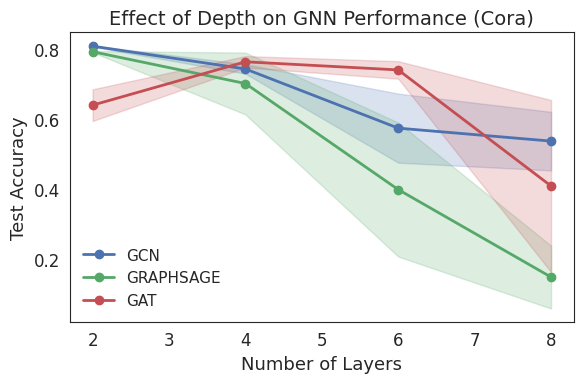

In [70]:
plt.figure(figsize=(6,4))

for model, data in results.items():

    layers = data["layers"]
    mean = np.array(data["acc_mean"])
    std = np.array(data["acc_std"])

    plt.plot(
        layers,
        mean,
        marker="o",
        linewidth=2,
        markersize=6,
        color=colors[model],
        label=model.upper()
    )

    # banda de variabilidad (mean ± std)
    plt.fill_between(
        layers,
        mean - std,
        mean + std,
        color=colors[model],
        alpha=0.2
    )

plt.xlabel("Number of Layers")
plt.ylabel("Test Accuracy")

plt.title("Effect of Depth on GNN Performance (Cora)")

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig("../results/plots/cora/accuracy_vs_layers.png", dpi=300)

plt.show()

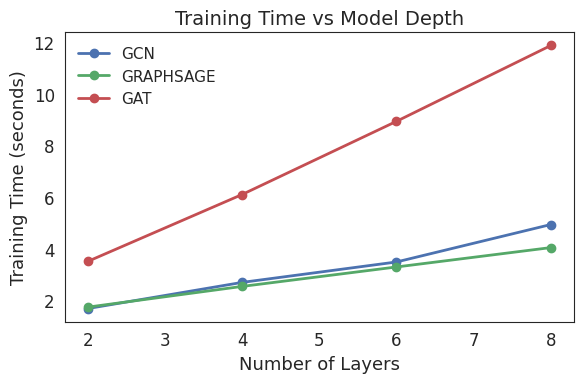

In [56]:
plt.figure(figsize=(6,4))

for model, data in results.items():

    plt.plot(
        data["layers"],
        data["time"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=colors[model],
        label=model.upper()
    )

plt.xlabel("Number of Layers")
plt.ylabel("Training Time (seconds)")

plt.title("Training Time vs Model Depth")

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig("../results/plots/time_vs_layers_cora.png", dpi=300)

plt.show()

In [58]:
rows = []
for model in results:
    for i in range(len(results[model]["layers"])):
        rows.append({
            "model": model,
            "layers": results[model]["layers"][i],
            "accuracy_mean": results[model]["acc_mean"][i],
            "accuracy_std": results[model]["acc_std"][i],
            "time": results[model]["time"][i]
        })

df = pd.DataFrame(rows)
df.to_csv("../results/tables/cora/gnn_layer_experiments.csv", index=False)

In [59]:
with open("../results/tables/cora/gnn_layer_experiments.json", "w") as f:
    json.dump(results, f, indent=4)

## Graph Structural Properties

Oversquashing is closely related to structural bottlenecks in the graph. Intuitively, if many nodes must communicate through a small number of edges, information from distant parts of the graph becomes compressed as it propagates.

One way to explore this is to analyze how the size of a node's neighborhood grows as the number of hops increases.

In [46]:
G = to_networkx(data, to_undirected=True)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print("Average degree:", avg_degree)

Number of nodes: 2708
Number of edges: 5278
Average degree: 3.8980797636632203


## Neighborhood Growth

If information could propagate freely through the graph, the number of reachable nodes should grow rapidly as the number of hops increases.

However, in graphs with structural bottlenecks, this expansion may be much slower. This means that information from large parts of the graph must be compressed through a limited number of edges, which is precisely the mechanism behind oversquashing.

The following analysis measures how the size of node neighborhoods grows as the hop distance increases.

In [ ]:
from collections import deque

def k_hop_neighbors(G, start, k):
    
    visited = {start}
    queue = deque([(start, 0)])
    
    while queue:
        node, depth = queue.popleft()
        
        if depth == k:
            continue
            
        for neighbor in G.neighbors(node):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, depth + 1))
                
    return len(visited)

sample_nodes = random.sample(list(G.nodes()), 200)

max_k = 12
growth = []

for k in range(1, max_k + 1):
    
    sizes = []
    
    for node in sample_nodes:
        sizes.append(k_hop_neighbors(G, node, k))
        
    growth.append(sum(sizes) / len(sizes))

## Expansion of k-hop neighborhoods

The following plot shows how the average number of reachable nodes grows with increasing hop distance.

If the expansion saturates quickly, it suggests that the graph contains structural bottlenecks that may restrict information flow.

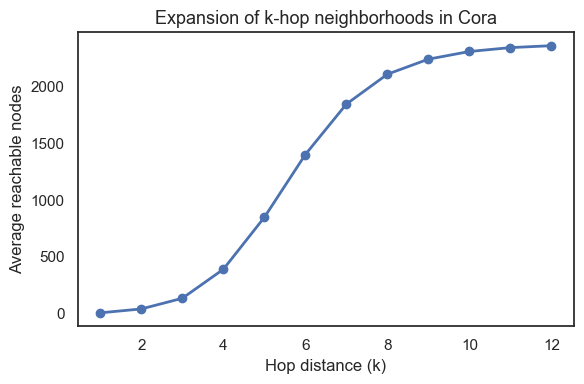

In [ ]:
plt.figure()

plt.plot(
    range(1, max_k + 1),
    growth,
    marker="o",
    linewidth=2,
)

plt.xlabel("Hop distance (k)")
plt.ylabel("Average reachable nodes")

plt.title("Expansion of k-hop neighborhoods in Cora")

plt.tight_layout()

plt.savefig(
    "../results/plots/khop_neighborhood_growth_cora.png",
    dpi=300
)

plt.show()

## Local Bottlenecks via Edge Betweenness Centrality

Although the global neighborhood expansion suggests that Cora does not exhibit a severe global bottleneck, oversquashing may still arise from local structural bottlenecks.

A standard way to identify such bottlenecks is through edge betweenness centrality. Edges with high betweenness lie on many shortest paths and may therefore act as narrow channels through which information from distant parts of the graph must pass.

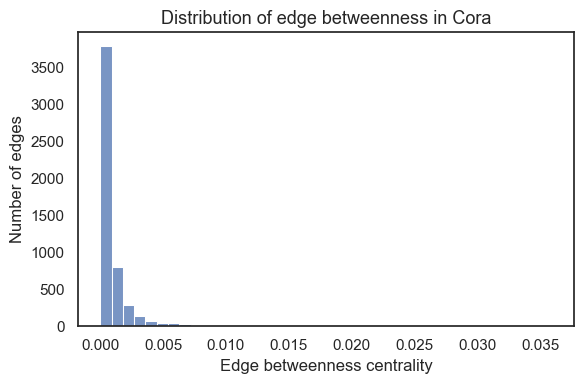

In [ ]:
import numpy as np

values = np.array(list(nx.edge_betweenness_centrality(G).values()))

plt.figure()

sns.histplot(
    values,
    bins=40,
    kde=False
)

plt.xlabel("Edge betweenness centrality")
plt.ylabel("Number of edges")

plt.title("Distribution of edge betweenness in Cora")

plt.tight_layout()

plt.savefig(
    "../results/plots/edge_betweenness_distribution_cora.png",
    dpi=300
)

plt.show()

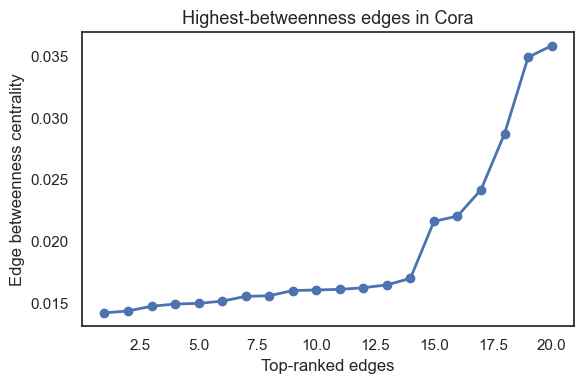

In [ ]:
top_values = np.sort(values)[-20:]

plt.figure()

plt.plot(
    range(1, len(top_values)+1),
    top_values,
    marker="o",
    linewidth=2
)

plt.xlabel("Top-ranked edges")
plt.ylabel("Edge betweenness centrality")

plt.title("Highest-betweenness edges in Cora")

plt.tight_layout()

plt.savefig(
    "../results/plots/highest_betweenness_edges_cora.png",
    dpi=300
)

plt.show()